Comparison at original x-values
----------------------------------------------
   x   actual y    polyfit     spline
 0.0     0.0000     0.0635     0.0000
 1.0     1.0000     0.6825     1.0000
 2.0     0.0000     0.6349     0.0000
 3.0     1.0000     0.3651     1.0000
 4.0     0.0000     0.3175     0.0000
 5.0     1.0000     0.9365     1.0000
Polyfit coefficients:
[ 0.07407407 -0.55555556  1.1005291   0.06349206]


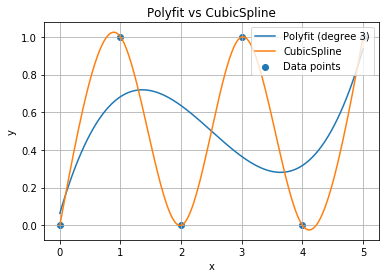

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Given data points
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 1, 0, 1, 0, 1], dtype=float)

#Polynomial fit, degree 3 for simple comparison choice
poly_coeffs = np.polyfit(x, y, 3)
poly = np.poly1d(poly_coeffs)

#Cubic spline interpolation
cs = CubicSpline(x, y, bc_type="natural")

#Smooth x-values for plotting
x_interp = np.linspace(0, 5, 200)
y_poly = poly(x_interp)
y_spline = cs(x_interp)

#print comparison at original points
print("Comparison at original x-values")
print("-" * 46)
print(f"{'x':>4} {'actual y':>10} {'polyfit':>10} {'spline':>10}")

for xi, yi in zip(x, y):
    print(f"{xi:>4.1f} {yi:>10.4f} {poly(xi):>10.4f} {cs(xi):>10.4f}")

print("Polyfit coefficients:")
print(poly_coeffs)

#plot
plt.scatter(x, y, label="Data points")
plt.plot(x_interp, y_poly, label="Polyfit (degree 3)")
plt.plot(x_interp, y_spline, label="CubicSpline")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polyfit vs CubicSpline")
plt.legend()
plt.grid(True)
plt.show()